## 설치·키·공통 함수

In [2]:
%%capture

# 필수 라이브러리 설치. "%%capture"는 이 셀의 출력을 숨깁니다
# (디버깅이 필요하면 이 줄을 주석 처리하세요).
%pip install pennylane pennylane-ionq requests

In [3]:
from functools import partial

import requests
import matplotlib.pyplot as plt
import pennylane as qml

# Colab Secrets(왼쪽 열쇠 아이콘)에 저장한 키를 읽어옵니다.
# 사전에 IONQ_API_KEY를 등록하고, 이 노트북에 대해 access 토글을 켜야 합니다.
from google.colab import userdata

api_key = userdata.get('IONQ_API_KEY')

# 측정 반복 횟수(shots). QPU는 실제 과금되므로 처음엔 작게 두는 것을 권장합니다.
SHOTS = 2048


def make_circuit(dev, shots):
    """주어진 디바이스에서 실행할 Bell 상태 회로(QNode)를 생성합니다.

    시뮬레이터와 QPU에 동일한 회로를 재사용하기 위해 팩토리로 분리했습니다.
    """
    @partial(qml.set_shots, shots=shots)
    @qml.qnode(dev)
    def circuit():
        qml.Hadamard(wires=0)          # qubit-0에 H 게이트 → 중첩 생성
        qml.CNOT(wires=[0, 1])         # 0을 제어, 1을 타깃으로 CNOT → 얽힘
        return qml.counts(all_outcomes=True)            # bitstring별 측정 횟수 반환
    return circuit


def normalize_counts(counts):
    """counts 값을 파이썬 int로 통일합니다.

    (numpy/torch 스칼라 등 어떤 타입이 와도 안전하게 변환)
    """
    return {k: int(v) for k, v in counts.items()}


def plot_counts(counts, title):
    """측정 결과(counts)를 막대그래프로 시각화합니다."""
    labels = sorted(counts)                 # bitstring을 정렬해 x축 순서 고정
    values = [counts[k] for k in labels]
    plt.bar(labels, values)
    plt.xlabel("bitstring")
    plt.ylabel("counts")
    plt.title(title)
    plt.show()

## 시뮬레이터: 계산 및 시각화 (먼저 완료)

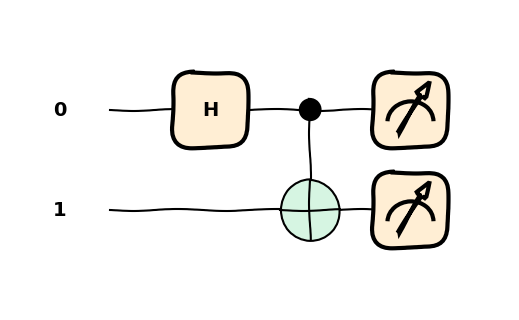

Simulator: {'00': 1022, '01': 0, '10': 0, '11': 1026}


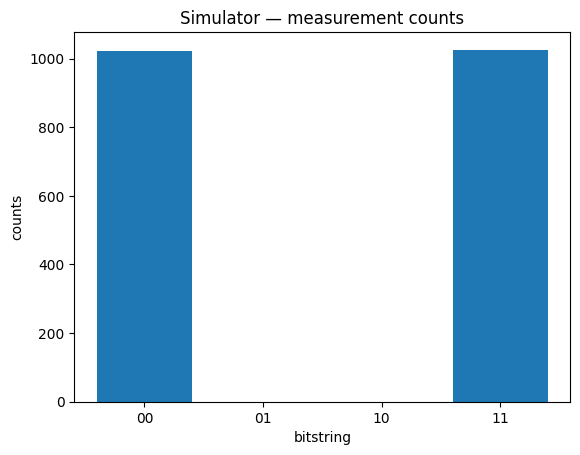

In [4]:
# ideal(무잡음) 트랩드-이온 시뮬레이터 디바이스.
sim_dev = qml.device("ionq.simulator", api_key=api_key, wires=2)
sim_circuit = make_circuit(sim_dev, SHOTS)

# 회로도 그리기. draw_mpl은 job을 제출하지 않으므로 과금이 없습니다.
qml.draw_mpl(sim_circuit, style="sketch")()
plt.show()

# 시뮬레이터 실행 + 결과 시각화. 이 셀만으로 완결되므로,
# 이후 QPU 단계가 오래 걸리거나 실패해도 시뮬레이터 결과는 확보됩니다.
sim_counts = normalize_counts(sim_circuit())
print("Simulator:", sim_counts)
plot_counts(sim_counts, "Simulator — measurement counts")

## QPU 사용량 조회 및 선택

In [5]:
# IONQ REST API 엔드포인트와 후보 QPU 목록.
# CANDIDATES는 IONQ 콘솔의 backend ID를 그대로 사용합니다.
IONQ_API_BASE = "https://api.ionq.co/v0.4"
CANDIDATES = ["qpu.forte-enterprise-1", "qpu.forte-1"]


def fetch_backends(api_key):
    """전체 백엔드의 현재 상태·큐 정보를 API에서 가져옵니다.

    반환값: 각 백엔드 dict의 리스트
    (backend, status, degraded, qubits, average_queue_time 등 포함).
    """
    resp = requests.get(
        f"{IONQ_API_BASE}/backends",
        headers={"Authorization": f"apiKey {api_key}"},  # 키 앞에 "apiKey " 접두
        timeout=30,
    )
    resp.raise_for_status()   # 2xx가 아니면 예외 발생
    return resp.json()


def _fmt_queue(seconds):
    """average_queue_time(초 단위)을 'Hh Mm Ss' 형태로 표시합니다."""
    if seconds is None:
        return "N/A"
    h, rem = divmod(int(seconds), 3600)
    m, s = divmod(rem, 60)
    return f"{h}h {m}m {s}s"


def choose_least_busy(backends, candidates):
    """후보 중 available 상태이면서 큐가 가장 짧은 백엔드를 선택합니다.

    선택 기준(우선순위):
      1) degraded=False 우선 (성능 저하 상태는 후순위)
      2) average_queue_time이 작은 것 우선 (덜 붐빔)
    """
    info = {b["backend"]: b for b in backends}   # 이름 → 정보 매핑

    # 후보들의 현황을 표로 출력
    print(f"{'backend':28} {'status':12} {'degraded':9} {'avg_queue':>14}")
    print("-" * 66)
    for name in candidates:
        b = info.get(name)
        if b is None:
            print(f"{name:28} {'NOT FOUND':12}")   # API 목록에 없는 경우
            continue
        print(f"{name:28} {b.get('status',''):12} "
              f"{str(b.get('degraded', False)):9} "
              f"{_fmt_queue(b.get('average_queue_time')):>14}")

    # available 상태인 후보만 남김
    usable = [
        info[name] for name in candidates
        if name in info and info[name].get("status") == "available"
    ]
    if not usable:
        raise RuntimeError("사용 가능한(available) 후보 백엔드가 없습니다.")

    # (degraded 여부, 큐 시간) 튜플로 정렬 → 최소값 선택
    best = min(
        usable,
        key=lambda b: (bool(b.get("degraded", False)),
                       b.get("average_queue_time", float("inf"))),
    )
    print(f"\n>>> 선택된 QPU: {best['backend']} "
          f"(queue={_fmt_queue(best.get('average_queue_time'))})")
    return best


backends = fetch_backends(api_key)
best = choose_least_busy(backends, CANDIDATES)

# PennyLane의 backend 인자는 "qpu." 접두어를 뗀 형태를 사용합니다.
qpu_backend = best["backend"].removeprefix("qpu.")

backend                      status       degraded       avg_queue
------------------------------------------------------------------
qpu.forte-enterprise-1       unavailable  False      1908h 32m 52s
qpu.forte-1                  available    False       1822h 7m 24s

>>> 선택된 QPU: qpu.forte-1 (queue=1822h 7m 24s)


## 현재 job 대기 상태 조회

In [6]:
# 아직 종료되지 않은(대기·실행 중) job 상태들.
# 종료 상태(completed/canceled/failed)는 제외합니다.
ACTIVE_STATUSES = ["submitted", "ready", "started"]


def _fmt_ms(ms):
    """밀리초 값을 'Hh Mm Ss'로 표시합니다 (predicted_*_ms 필드용)."""
    if ms is None:
        return "N/A"
    return _fmt_queue(int(ms) / 1000)   # ms → s 변환 후 재사용


def fetch_jobs(api_key, status=None, limit=50):
    """프로젝트의 job 목록을 조회합니다. status로 서버 측 필터링 가능."""
    params = {"limit": limit}
    if status:
        params["status"] = status
    resp = requests.get(
        f"{IONQ_API_BASE}/jobs",
        headers={"Authorization": f"apiKey {api_key}"},
        params=params,
        timeout=30,
    )
    resp.raise_for_status()
    return resp.json().get("jobs", [])   # 응답은 {"jobs": [...], "next": ...}


def show_pending_jobs(api_key):
    """대기·실행 중인 job을 상태별로 모아 표로 출력합니다."""
    pending = []
    for st in ACTIVE_STATUSES:
        pending.extend(fetch_jobs(api_key, status=st))

    if not pending:
        print("대기·실행 중인 job이 없습니다. (제출한 job이 모두 종료되었거나 없음)")
        return pending

    # 제출 시각(오래된 순)으로 정렬
    pending.sort(key=lambda j: j.get("submitted_at") or "")

    print(f"대기·실행 중 job: {len(pending)}건\n")
    print(f"{'id':10} {'status':10} {'backend':22} "
          f"{'submitted_at':22} {'pred_wait':>14}")
    print("-" * 82)
    for j in pending:
        jid = (j.get("id") or "")[:8]                    # UUID 앞 8자리만 표시
        print(f"{jid:10} {j.get('status',''):10} "
              f"{j.get('backend',''):22} "
              f"{(j.get('submitted_at') or 'N/A'):22} "
              f"{_fmt_ms(j.get('predicted_wait_time_ms')):>14}")
    return pending


pending_jobs = show_pending_jobs(api_key)

대기·실행 중 job: 12건

id         status     backend                submitted_at                pred_wait
----------------------------------------------------------------------------------
019f8a55   completed  simulator              2026-07-22T14:58:28.323Z            N/A
019f8a55   completed  qpu.forte-1            2026-07-22T14:58:34.328Z            N/A
019f8a5a   completed  simulator              2026-07-22T15:03:40.998Z            N/A
019f8a5e   completed  qpu.forte-1            2026-07-22T15:07:54.762Z            N/A
019f8a79   completed  qpu.forte-1            2026-07-22T15:37:06.762Z            N/A
019f8a83   completed  simulator              2026-07-22T15:47:52.725Z            N/A
019f8a83   completed  qpu.forte-1            2026-07-22T15:47:59.707Z            N/A
019f8b4f   canceled   qpu.forte-1            2026-07-22T19:31:42.451Z            N/A
019f8b64   completed  simulator              2026-07-22T19:54:14.419Z            N/A
019f8b66   completed  simulator              2026-0

## 선택 요약 (선택)

In [7]:
# 앞 셀에서 확보한 best/qpu_backend를 사람이 읽기 좋게 재요약
print("선택된 실행 백엔드")
print(f"  - backend        : {best['backend']}")
print(f"  - status         : {best.get('status')}")
print(f"  - degraded       : {best.get('degraded', False)}")
print(f"  - avg_queue_time : {_fmt_queue(best.get('average_queue_time'))}")
print(f"  - PennyLane 인자 : backend=\"{qpu_backend}\"")

선택된 실행 백엔드
  - backend        : qpu.forte-1
  - status         : available
  - degraded       : False
  - avg_queue_time : 1822h 7m 24s
  - PennyLane 인자 : backend="forte-1"


## QPU: 실행 및 시각화 (시뮬레이터 이후)
- qpu_dev = qml.device("ionq.qpu", backend=qpu_backend, api_key=api_key, wires=2,  error_mitigation={"debias": False})

In [ ]:
# 앞에서 선택된, 덜 붐비는 QPU 디바이스를 생성합니다.
## 주의점.
### qpu_dev = qml.device("ionq.qpu", backend=qpu_backend, api_key=api_key, wires=2)
qpu_dev = qml.device("ionq.qpu", backend=qpu_backend, api_key=api_key, wires=2,
                     error_mitigation={"debias": False})
qpu_circuit = make_circuit(qpu_dev, SHOTS)

# 주의: 아래 호출은 실제 QPU에 job을 제출합니다.
#       → 큐 대기 시간이 발생하고, 실제 과금됩니다.
qpu_counts = normalize_counts(qpu_circuit())
print(f"QPU ({qpu_backend}):", qpu_counts)
plot_counts(qpu_counts, f"QPU ({qpu_backend}) — measurement counts")

## 시뮬레이터 vs QPU 비교

In [ ]:
# 두 결과에 등장한 모든 bitstring을 합쳐 x축 기준을 통일합니다.
# (한쪽에만 나온 outcome은 다른 쪽에서 0으로 처리)
all_labels = sorted(set(sim_counts) | set(qpu_counts))
sim_vals = [sim_counts.get(k, 0) for k in all_labels]
qpu_vals = [qpu_counts.get(k, 0) for k in all_labels]

# 막대를 좌우로 살짝 어긋나게 배치해 나란히 비교
x = range(len(all_labels))
w = 0.4
fig, ax = plt.subplots()
bars_sim = ax.bar([i - w/2 for i in x], sim_vals, width=w, label="simulator")
bars_qpu = ax.bar([i + w/2 for i in x], qpu_vals, width=w, label=f"qpu:{qpu_backend}")

# 각 막대 위에 counts 값을 숫자로 표시
ax.bar_label(bars_sim, padding=2)
ax.bar_label(bars_qpu, padding=2)

ax.set_xticks(list(x))
ax.set_xticklabels(all_labels)
ax.set_xlabel("bitstring")
ax.set_ylabel("counts")
ax.set_title("Simulator vs QPU")
ax.legend()

# 라벨이 상단에 잘리지 않도록 y축 여유 확보
ax.margins(y=0.1)

plt.show()